FEUILLE DE TP 6

---
# Intégration numérique (Partie 1) :  Apprentissage du cours
---

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np                       # pour les numpy array
import matplotlib.pyplot as plt          # librairie graphique 

Dans ce TP, nous allons programmer et étudier qualques formules de quadrature élémentaires et les formules composites associées. 

## I-  Préliminaires : Quelques fonctions à intégrer

Nous testerons les formules de quadratures sur quelques fonctions. Nous prendons les suivantes :
\begin{align}
f_0(x) &= \exp(-x), &
f_1(x) &= \frac{\exp(-x^2)}{2},&
f_2(x) &= \sqrt{\sin x},\\
%f_2(x) &= 0.1 \,(1+x/3)^3 \log(1+x),&
%f_3(x) &= \sin(2\pix) / (1.1 - \sin(\pix)).
\end{align}

### Question I-1: visualisations

>- 1- Définissez ces 3 fonctions et tracez les sur l'intervalle $[0, 3]$.
>- 2- Achurer l'aire du domaine correspondant à la valeur de l'intérale $I = \int_0^3  f(x) \, dx$. <br> (*on pourra se renseigner sur la fonction `fill_between` de `matplotlib`*).    

In [2]:
def f0(x):
    return np.exp(-x)

def f1(x):
    return np.exp(-x**2)/2

def f2(x):
    return np.sqrt(np.sin(x))

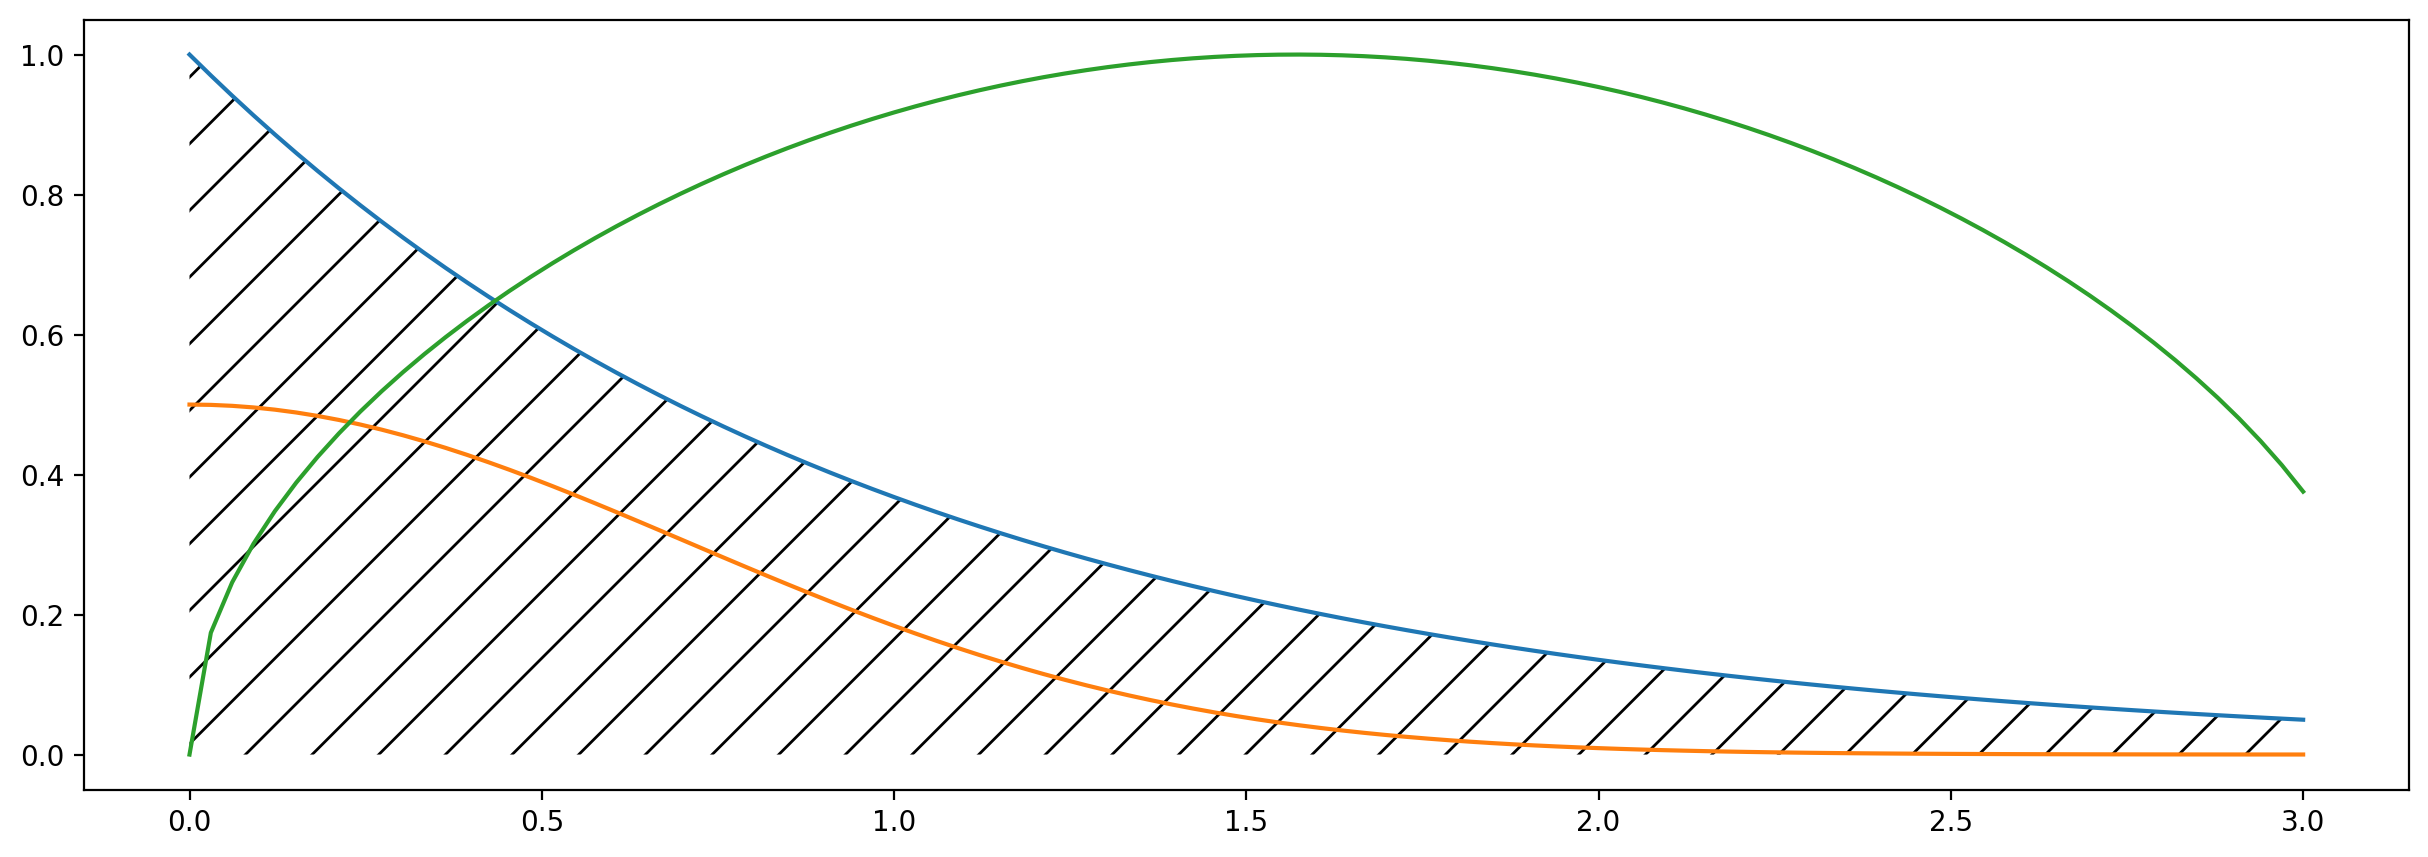

In [11]:
x = np.linspace(0,3,100)
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(111)
ax.plot(x,f0(x))
ax.plot(x,f1(x))
ax.plot(x,f2(x))
ax.fill_between(x,f0(x),hatch="/",facecolor="white")
plt.show()

## II-  Intégration en utilisant le module `scipy`

La fonction `quad` de `scipy.integrate` permet de calculer la valeur approchée d'une intégrale à une précision donnée. Lisez attentivement la documentation https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html. 

### Question II-1 : Calculs

> Calculer les intégrales de $f_i$, $ i = 0, 1, 2 $, sur $[0, 0.1]$ en utilisant la fonction `quad` de `scipy.integrate`. On choissira une erreur absolue `epsabs=1e-14`. 

In [12]:
from scipy.integrate import quad 

# COMPLETEZ    

In [14]:
help(scipy.integrate.quad)

NameError: name 'scipy' is not defined

### Question II-2 : Une validation 
    
>* Pour $ i = 0 $ comparer la valeur obtenue avec la valeur de l'intégrale calculée à la main.
>* Commentez le résultat.

## III-  Construction de formules de calcul à points de quadrature donnés

Pour calculer les inégrales, on peut découper le domaine d'intégration en des sous intervalles et appliquer sur chacun de ses sous-intervalles une formule d'intégration assez **simple** appelée  **formule de quadrature élémentaire**. Et cette formule d'intégration résultante d'une sommation des résultats d'une formule élémentaire sur des sous-intervalles est appélée **formule de quadrature composite**. 

Nous allons analyser quelques formules de quadrature élémenatires ainsi que les formules composites associées.
   
**REMARQUE IMPORTANTE  :** pour l' **analyse d'erreurs**, vous pourrez si vous le pouvez, vous servir **en la modifiant légèrement** de la fonction `TraquerOrdre` du `TP03`.  


## III-1 Quelques formules élémentaires (voir cours)

![Formules élémentaires](formules_elementaires.jpg)

### III-1-1 Formule du rectangle

On distingue une formule du **rectangle à gauche** et une formule du **rectangle àd roite**.

La formule du rectangle à gauche consiste à faire l'approximation

\begin{equation}
\int_{a}^{b} f(x) \, dx \approx J^R( f ) = (b-a) f(a).
\end{equation}

#### Question III-1-1-1 : Mise en oeuvre

> 1. Programmez une fonction `quad_rect(f,a,b)` qui prend en argument une fonction `f` et deux réels `a` et `b`, et qui retourne la valeur approchée de  $ \int_a^b f(x)dx $ obtenue par la formule du rectangle.
> 2. Calculez les valeurs approchées des intégrales de $ f_i $, $ i = 0, 1, 2 $, sur $ [ 0, 0.1 ] $, comparez les valeurs obtenues avec celles de la question précédente.

In [1]:
def quad_rect(f, a, b):
    """méthode du rectangle à gauche"""
    ...

#### Question III-1-1-2 : Etude du comportement d'erreur

On supposera que $ a = 0 $ et $ b = h $. On utilisera la notation $ J^R_h( f ) = J^R( f ) $ dans ce cas.

> 1. Calculez les valeurs approchée de $I_h(f_0) = \int_{0}^{h}f_0(x)dx $ à l'aide de la formule du rectangle pour $h=\lbrace 1, 1/2, 1/4, \ldots, 2^{-10}\rbrace$. 
> 2. Affichez alors en respectant le format ci-dessous au maximum les valeurs de $h$, $E_h(f_0)$, $E_h(f_0)/h$ et $E_h(f_0)/h^2$, où $E_h(f_0)=\vert I_h( f_0 )-J^R_h( f_0 )\vert$ :

```
-----------------------------------------------
  h         Eh(f0)/h^0  Eh(f0)/h^1  Eh(f0)/h^2
-----------------------------------------------
 1.000e+00  3.6788e-01  3.6788e-01  3.6788e-01
 5.000e-01  1.0653e-01  2.1306e-01  4.2612e-01
 2.500e-01  2.8801e-02  1.1520e-01  4.6081e-01
...
-----------------------------------------------
```

*Rappel : voici un exemple pour écrire le nombre 0.14159 sous la forme `1.4159e-01`*
```python
print(f"{0.14159:11.4e}")
```

> 3. Comparez la convergence de $ E_h( f_0 ) $ vers $ 0 $  à celle d'une puissance de $ h $ vers 0. Les résultats obtenus sont-ils conformes aux résultats vus en cours?

### III-1-2 Formule du point milieu

Elle est définie par :
\begin{equation}
\int_{a}^{b} f(x) \, dx \approx J^M( f ) = (b-a) f\left(\frac{a + b}{2}\right).
\end{equation}



#### Question III-1-2-1 : Mise en oeuvre

> 1. Programmez une fonction `quad_milieu(f,a,b)` qui prend en argument une fonction `f` et deux réels `a` et `b`, et qui retourne la valeur approchée de  $ \int_a^b f(x)dx $ obtenue par la formule du rectangle.
> 2. Calculez les valeurs approchées des intégrales de $ f_i $, $ i = 0, 1, 2 $, sur $ [ 0, 0.1 ] $, comparez les valeurs obtenues avec celles de la question précédente.

In [2]:
def quad_milieu(f, a, b):
    """méthode du point milieu """
    ...

#### Question III-1-2-2 : Etude du comportement d'erreur

> 1. Calculez les valeurs approchée de $I_h(f_0) = \int_{0}^{h}f_0(x)dx $ à l'aide de la formule du rectangle pour $h=\lbrace 1, 1/2, 1/4, \ldots, 2^{-10}\rbrace$. 
> 2. Affichez alors en respectant le format ci-dessous au maximum les valeurs de $h$, $E_h(f_0)$, $E_h(f_0)/h$,  $E_h(f_0)/h^2$, et $E_h(f_0)/h^3$ où $E_h(f_0)=\vert I_h( f_0 )-J^M_h( f_0 )\vert$ :
> 3. Comparez la convergence de $ E_h( f_0 ) $ vers $ 0 $  à celle d'une puissance de $ h $ vers 0. Les résultats obtenus sont-ils conformes aux résultats vus en cours?

### III-1-3 Formule du trapèze

Elle est définie par :
\begin{equation}
\int_{a}^{b} f(x)\, dx \approx J^T(f) = (b - a) \frac{f(a)+f(b)}{2} 
\end{equation}


Reprendre les questions  **Question III-1-2-1** et **Question III-1-2-2** en mettant en oeuvre cette fois une fonction `quad_trapeze(f, a, b)`.

In [3]:
def quad_trapeze(f, a, b):
    """  """
    ...

### III-1-3 Formule de Simpson

Elle est définie par :
\begin{equation}
\int_{a}^{b} f(x) \, dx \approx J^S( f ) = \left( \frac{b-a}{6}\right) \left(f(a) + 4 f\left(\frac{a + b}{2}\right)  + f(b) \right).
\end{equation}

Reprendre les questions  **Question III-1-2-1** et **Question III-1-2-2** en mettant en oeuvre cette fois une fonction `quad_simpson(f, a, b)`.

(**Il faudra bien choisir la bonne valeur maximale de $r$ lorsqu'on affichera $E_h(f_0)/h^r $ pour quelques valeurs $ r \in \mathbb{N}$, afin de tirer la conclusion**).

## III-2 Quelques formules composites (voir cours)

Étant donnée une fonction $f : [a,b] \to \mathbb{R}$, et une subdivision $a = x_0 < x_1 < \ldots x_n = b$, on décompose $\int_a^b f(x)\, dx$ par la relation de Chasles
\begin{equation}
\int_a^b f(x) \, dx = \sum_{i=0}^{n-1} \int_{x_i}^{x_{i+1}} f(x)\, dx
\end{equation}
et on calcule une approximation de l'intégrale sur chaque sous-intervalle $[x_i,x_{i+1}]$ à l'aide d'une formule de quadrature élémentaire $I_e(f;[x_i,x_{i+1}])$
\begin{equation} \int_{x_i}^{x_{i+1}} f(x)\, dx \approx I_e(f ; [x_i,x_{i+1}]).
\end{equation}

![Formules composites](formules_composites.jpg)

### III-2-0  Préliminaires
Afin de mettre en Oeuvre une formule de qudrature composite 
Commencer par fournir une fonction  

`quad_composite(f, x, quad_elem)` qui prend en argument :
>- la fonction a intégrer`f`
>- un `ndarray`  `x` qui contient la noeuds $x_i,i=0,\ldots,n$ de la subdivision de $[a,b]$ ( il est clair que $x_0 =a$, et $x_n = b$)
>- une fonction `quad_elem` qui est la formule de quadrature élémentaire (comme définie dans la partie **III-1**)  à utiliser pour le calcul approché de l'intégrale : C'est-à-dire `quad_elm(f,x_i, x_{i+1})` est la valeur de $I_e(f ; [x_i,x_{i+1}])$.


**Remarque**: Vous pourrez optimiser (si vous le voulez) les analyses faîtes ci-dessous en factorisant tout ce qui est décrit car  
le nom de la fonction `quad_elem` passée en paramètre peut être récupéré dans la fonction appelante dans la chaîne de caractères `quad_elm.__name__`. 

In [4]:
def quad_composite(f, x, quad_elem):
    #print(quad_elem.__name__)
    ...

In [5]:
# TESTEZ ICI


### III-2-1 Formule (composite) des rectangles

Dans cette formule, la formule de quadrature élémentaire est celle du rectangle.



#### Question III-2-1-1 : Mise en oeuvre

>*  Proposez une fonction `quad_comp_rect (f, x)` qui prend en arguments:  `f` une fonction, et `x` le noeuds  
d'une subivision d'un intervalle $[a,b]$ ( `a` et `b` sont identifiés par le premier et le dernier élément de `x`) 
et qui retourne la valeur approchée de l'intégrale de $f$ en entre $a$ et $b$ par la formule composite des rectangles à gauche.
 

In [6]:
#Mise en oeuvre

def quad_comp_rect (f, x):
    """ """
    ...

#### Question III-2-1-2 : Validation

>* Calculez les valeurs approchées des intégrales de $ f_i $, $ i = 0, 1, 2 $, sur $ [ 0, 3] $, en utilisant 
la formule composite  des rectangles à gauche, et une subdivision uniforme en N = 100 sous intervalles. Comparez les valeurs obtenues avec celles obtenue avec `quad`.

In [7]:
# Validations

# LE FORMATAGE N'EST PAS OBLIGATOIRE


#### Question III-2-1-3 : Etude du comportement d'erreur

On va encore une fois déterminer le comportement de l'erreur entre la formule composite et la solution exacte qui sera fournie par `quad` (attention à la valeur de l'erreur absolue tolérée à fournir à avec cette fonction).

Pour une subdivision d'un intervalle $[a, b]$ identifée par ses noeuds $a\leq x_0 < \ldots < x_N = b$, on va encore désigner par $E_h^c = |I_{a,b}(f) - I_{a,b;h}^c(f)|$ l'erreur entre la valeur de l'intégrale $I_{a,b}(f)$ et la valeur approchée $I_{a,b;h}^c (f)$. Ici, $h$ désigne le pas de la subdivision i.e $\displaystyle h = \max_{0\leq i < N} |x_{i+1} - x_i |$.
(*ce calcul n'étant pas nécessaire pour une subdivision uniforme*).

On peut alors procéder comme dans les questions ci-dessus pour estimer l'ordre (vitesse) de convergence de la formule composite :
 
 
> 1. Pour $h = \frac{b-a}{2^i}$, $i = 0, \ldots, 10$,  affichez alors en respectant le format ci-dessous les valeurs de $h$, $E_h^c$ et  
$$\frac{ \log( E_h^c(f_0) ) - \log( E_{h/2}^c(f_0) )  }{\log2}
\quad \textrm{ou encore} \quad 
\frac{ \log\left(\frac{ E_h^c(f_0)}{E_{h/2}^c(f_0) } \right)}{\log(2)} 
$$
```
-------------------------------------------------------------------------
|          h           |          Eh          | log(E_h/E_{h/2})/log(2) |
-------------------------------------------------------------------------
|       3.00E+00       |      2.0498E+00      |            -            |
|       1.50E+00       |      8.8448E-01      |          1.21           |
|       7.50E-01       |      4.0046E-01      |          1.14           |
|       3.75E-01       |      1.8927E-01      |          1.08           |
...
-------------------------------------------------------------------------
```

> 2. Comparez la convergence de $ E_h( f_0 ) $ vers $ 0 $  à celle d'une puissance de $ h $ vers 0. Les résultats obtenus sont-ils conformes aux résultats vus en cours?


In [8]:
# Estimation de l'ordre de convergenc
a, b = 0., 3. 

### III-2-2 Formule (composite) du point milieu 

#### Question III-2-2-1 : Mise en oeuvre
Reprendre la question **III-2-1-1** cette fois avec une fonction `quad_comp_milieu`.


In [9]:
# Mise en oeuvre
def quad_comp_milieu(f, x):
    """  """
    ...

#### Question III-2-2-2 : Validation
Reprendre la question **III-2-1-2** pour cette formule.

In [10]:
# Validations


#### Question III-2-2-3 : Etude du comportement d'erreur
Reprendre la question **III-2-1-3** pour cette formule. Pour estimer l'ordre de convergence de cette méthode.

In [11]:
# Estimation de l'ordre de convergence


### III-2-3 Formule (composite) des trapèzes

Reprendre la démarche de la partie **III-2-2** ci-dessus avec cette fois `quad_comp_trapezes` 


In [12]:
# Mise en oeuvre

In [13]:
# Validations

In [14]:
# Estimation de l'ordre de convergence

### III-2-4 Formule (composite) de Simpson

En vous inspirant de ce qui précède, analysez la formule de quadrature composite de Simpson.

